# Lab 1 Environment Setup
Before starting this lab, we need to set up our Python environment. Follow these steps in your terminal:

First, we'll create a new conda environment named 'lab_1' with Python 3.9:

```conda create --name lab_1 python=3.9 ```


After the environment is created, activate it:

```conda activate lab_1 ```


Install the IPython kernel to enable the environment in Jupyter: 

```conda install ipykernel ```

Note: Make sure you have Anaconda or Miniconda installed on your system before running these commands. After completing these steps, you'll have a clean Python 3.9 environment ready for the lab exercises.

To verify your setup:

- Your terminal prompt should show (lab_1) indicating the environment is active

- Running python --version should show Python 3.9.x

- The environment should be available as a kernel option in Jupyter

Now you're ready to proceed with the lab exercises!

In [38]:
!pip install --quiet torch torchvision matplotlib scikit-learn pandas

In [1]:
import torch
import torch.nn as nn

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('GPU State:', device)

GPU State: cpu


In [133]:
df = pd.read_csv('oxford_flower_102_name.csv')
flower_mapper = dict(zip(df['Index'], df['Name']))
label_list = list(flower_mapper.values())

In [207]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, std: float = 0.1):
        """
        Initialize a linear layer with random weights.

        Weights and biases are registered as parameters, allowing for 
        gradient computation and update during backpropagation.
        """
        super(Linear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        self.to(device=device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform linear transformation by multiplying the input tensor
        with the weight matrix, and adding the bias.
        """
        return torch.matmul(x, self.weight.t()) + self.bias


    def __repr__(self) -> str:
        return f'in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}'

In [208]:
class ReLU(nn.Module):
    """
    Rectified Linear Unit (ReLU) activation function.
    """

    @staticmethod
    def forward(x: torch.Tensor) -> torch.Tensor:
        return torch.clip(x, 0.)

In [209]:
class Dropout(nn.Module):
    """
    Applies the dropout regularization technique to the input tensor.

    During training, it randomly sets a fraction of input units to 0 with probability `p`,
    scaling the remaining values by `1 / (1 - p)` to maintain the same expected output sum.
    During evaluation, no dropout is applied.
    """

    def __init__(self, p=0.2):
        super(Dropout, self).__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            mask = (torch.rand(x.shape) > self.p).float().to(x) / (1 - self.p)
            return x * mask
        return x

In [210]:
class Flatten(nn.Module):
    """
    Reshape the input tensor by flattening all dimensions except the first dimension.
    """

    @staticmethod
    def forward(x: torch.Tensor) -> torch.Tensor:
        """
        x.view(x.size(0), -1) reshapes the x tensor to (x.size(0), N)
        where N is the product of the remaining dimensions.
        E.g. (batch_size, 28, 28) -> (batch_size, 784)
        """
        return x.reshape(x.size(0), -1)  # Will automatically flatten to (batch_size, 3*28*28)


In [211]:
class Sequential(nn.Module):
    """
    Sequential container for stacking multiple modules,
    passing the output of one module as input to the next.
    """

    def __init__(self, *layers):
        super(Sequential, self).__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x

    def __repr__(self) -> str:
        layer_str = '\n'.join([f' ({i}): {layer}' for i, layer in enumerate(self.layers)])
        return f'{self.__class__.__name__}(\n{layer_str}\n)'

In [224]:
class Classifier(nn.Module):
    """
    Classifier model consisting of a sequence of linear layers and ReLU activations,
    followed by a final linear layer that outputs logits (unnormalized scores)
    for each of the 10 garment classes.

    It encapsulates also a method to convert logits into a label/probability dict.
    """

    def __init__(self):
        """
        The output logits of the last layer can be passed directly to
        a loss function like CrossEntropyLoss, which will apply the 
        softmax function internally to calculate a probability distribution.
        """
        super(Classifier, self).__init__()
        self.labels = label_list
        
        self.main = Sequential(
            Flatten(),
            Linear(in_features=2352, out_features=1024),
            ReLU(),
            Dropout(0.2),
            Linear(in_features=1024, out_features=512),
            ReLU(),
            Dropout(0.2),
            Linear(in_features=512, out_features=len(label_list)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.main(x)
    
    def predictions(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.nn.functional.softmax(logits, dim=1)
            predictions = dict(zip(self.labels, probs.cpu().detach().numpy().flatten()))    
        return predictions

In [225]:
model = Classifier().to(device)
model

Classifier(
  (main): Sequential(
   (0): Flatten()
   (1): in_features=2352, out_features=1024, bias=True
   (2): ReLU()
   (3): Dropout()
   (4): in_features=1024, out_features=512, bias=True
   (5): ReLU()
   (6): Dropout()
   (7): in_features=512, out_features=102, bias=True
  )
)

In [214]:
list(model.parameters())[0]

Parameter containing:
tensor([[ 0.0032, -0.0095, -0.0204,  ...,  0.0152, -0.0014,  0.0367],
        [ 0.0059, -0.0113,  0.0340,  ..., -0.0145,  0.0225, -0.0121],
        [-0.0147, -0.0111, -0.0052,  ...,  0.0478,  0.0355,  0.0032],
        ...,
        [-0.0294, -0.0320,  0.0045,  ..., -0.0353,  0.0262,  0.0497],
        [-0.0116, -0.0033, -0.0101,  ..., -0.0111, -0.0075, -0.0324],
        [-0.0037, -0.0281, -0.0023,  ..., -0.0338, -0.0108,  0.0050]],
       requires_grad=True)

In [226]:
class Optimizer:
    """
    Update model parameters during training.
    
    It performs a simple gradient descent step by updating the parameters
    based on their gradients and the specified learning rate (lr).
    """

    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def step(self):
        for p in self.params:
            p.data -= p.grad.data * self.lr

    def zero_grad(self):
        """
        Reset the gradients of all parameters to zero.
        Since PyTorch accumulates gradients, this method ensures that
        the gradients from previous optimization steps do not interfere
        with the current step.
        """
        for p in self.params:
            p.grad = None

In [227]:
from dataclasses import dataclass

@dataclass
class LearnerConfig:
    """
    Configuration class for the Learner.

    This class holds the hyperparameters and settings for training the model.
    """

    model: nn.Module
    criterion: nn.Module
    epochs: int
    batch_size: int
    lr: float
    device: str

# Example configuration
config = LearnerConfig(
    model=model,
    criterion=nn.CrossEntropyLoss(),
    epochs=25,
    batch_size=64,
    lr=0.005,
    device=device,
)

In [228]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Basic transforms
basic_transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Resize images to 224x224
    transforms.ToTensor()  # Convert PIL Image to tensor
    #transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
    #                   std=[0.229, 0.224, 0.225])
])



In [218]:
from torchvision.transforms import ToTensor
from torchvision import datasets
from torch.utils.data import DataLoader

train_data = datasets.Flowers102(root = '', split = "train", transform = basic_transform, download = True)
test_data = datasets.Flowers102(root = '', split = "test", transform = basic_transform)

loaders = {'train' : DataLoader(train_data, batch_size=config.batch_size, shuffle=True, num_workers=2),
           'test'  : DataLoader(test_data, batch_size=config.batch_size, shuffle=False, num_workers=2)}

In [219]:
print(train_data)

Dataset Flowers102
    Number of datapoints: 1020
    Root location: 
    split=train
    StandardTransform
Transform: Compose(
               Resize(size=(28, 28), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [220]:
import scipy.io
import numpy as np

# Load the .mat file
mat = scipy.io.loadmat('flowers-102/imagelabels.mat')

id = scipy.io.loadmat('flowers-102/setid.mat')

print(id)
# Extract the labels
# The labels are typically stored in a key like 'labels' or 'imagelabels'
# Convert to 0-based indexing (subtract 1 since MATLAB uses 1-based indexing)
labels = mat['labels'][0] - 1


# Now labels is a numpy array containing the class labels
print(f"Number of images: {len(labels)}")
print(f"Label range: {np.min(labels)} to {np.max(labels)}")
print(f"Number of unique classes: {len(np.unique(labels))}")


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 17:38:58 2009', '__version__': '1.0', '__globals__': [], 'trnid': array([[6765, 6755, 6768, ..., 8026, 8036, 8041]], dtype=uint16), 'valid': array([[6773, 6767, 6739, ..., 8028, 8008, 8030]], dtype=uint16), 'tstid': array([[6734, 6735, 6737, ..., 8044, 8045, 8047]], dtype=uint16)}
Number of images: 8189
Label range: 0 to 101
Number of unique classes: 102


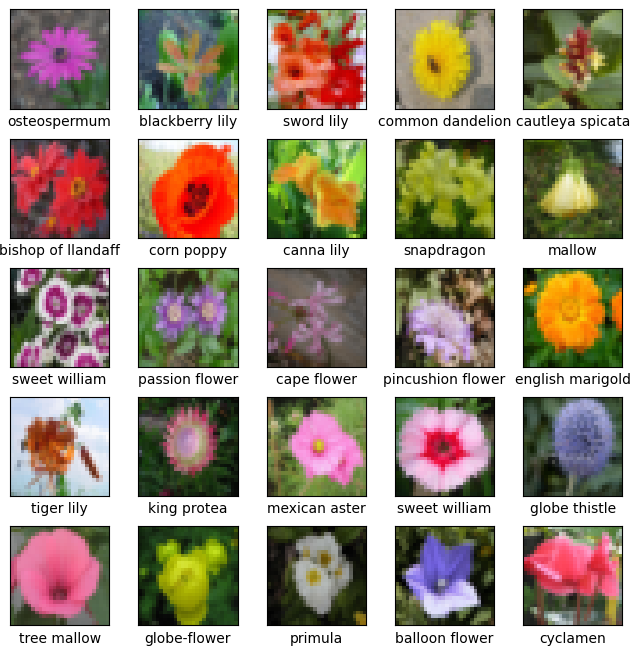

In [202]:
import matplotlib.pyplot as plt 

figure = plt.figure(figsize=(8, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.xticks([])
    plt.yticks([])
    img_transposed = np.transpose(img, (1, 2, 0))
    plt.imshow(img_transposed.squeeze())
    plt.xlabel(flower_mapper[label])
plt.subplots_adjust(hspace=0.3)
plt.show()

In [203]:
img.size()

torch.Size([3, 28, 28])

In [229]:
from sklearn.metrics import precision_score, recall_score, f1_score

class Learner:
    """
    Learner class for training and evaluating a model.

    This class encapsulates the training and validation loops, as well as
    utility methods for prediction, exporting the model, and calculating
    accuracy.
    """

    def __init__(self, config, loaders):
        """
        Initialize the Learner.

        Args:
            config (LearnerConfig): Configuration for the Learner.
            loaders (dict): Dictionary of data loaders for training and testing.
        """
        self.model = config.model
        self.loaders = loaders
        self.optimizer = Optimizer(self.model.parameters(), config.lr)
        self.criterion = config.criterion
        self.epochs = config.epochs
        self.device = config.device
        self.labels = list(flower_mapper.values())
        self.model.to(self.device)

    def train_epoch(self, epoch):
        """
        Train the model for one epoch.
        """
        epoch_loss = 0.0
        for x, y in self.loaders["train"]:
            x, y = x.to(self.device), y.to(self.device)
            batch_size = x.size(0)

            # Zero out the gradients - otherwise, they will accumulate.
            self.optimizer.zero_grad()
   
            # Forward pass, loss calculation, and backpropagation
            output = self.model(x)
            loss = self.criterion(output, y)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item() * batch_size

        train_loss = epoch_loss / len(self.loaders['train'].dataset)
        return train_loss
    
    def valid_loss(self):
        """
        Calculate the validation loss.
        """
        self.model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in self.loaders["test"]:
                x, y = x.to(self.device), y.to(self.device)
                output = self.model(x)
                val_loss += self.criterion(output, y).item() * y.size(0)
        val_loss /= len(self.loaders["test"].dataset)
        return val_loss

    def batch_accuracy(self, x, y):
        """
        Calculate the accuracy for a batch of inputs (x) and targets (y).
        """        
        _, preds = torch.max(x.data, 1)
        return (preds == y).sum().item() / x.size(0)

    def validate_epoch(self):
        """
        Evaluate the model on the test dataset after an epoch.
        """        
        accs = [self.batch_accuracy(self.model(x.to(self.device)), y.to(self.device))
                for x, y in self.loaders["test"]]
        return sum(accs) / len(accs)
            
    def fit(self):
        """
        Train the model for the specified number of epochs.
        """
        print('epoch\ttrain_loss\tval_loss\ttest_accuracy')
        for epoch in range(self.epochs):
            train_loss = self.train_epoch(epoch)
            valid_loss = self.valid_loss()
            batch_accuracy = self.validate_epoch()
            print(f'{epoch+1}\t{train_loss:.6f}\t{valid_loss:.6f}\t{batch_accuracy:.6f}')

        metrics = self.evaluate()
        return metrics
    
    def export(self, path):
        torch.save(self.model, path)
                            
    def evaluate(self):
        self.model.eval()
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for x, y in self.loaders["test"]:
                x, y = x.to(self.device), y.to(self.device)
                outputs = self.model(x)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())

        class_precision = precision_score(all_targets, all_preds, average=None)
        class_recall = recall_score(all_targets, all_preds, average=None)
        class_f1 = f1_score(all_targets, all_preds, average=None)

        metrics = {label: {"precision": prec, "recall": rec, "f1": f1}
                   for label, prec, rec, f1 in zip(self.labels, class_precision, class_recall, class_f1)}

        return metrics

In [230]:
learner = Learner(config, loaders)

In [231]:
metrics = learner.fit()

epoch	train_loss	val_loss	test_accuracy
1	4.657240	4.632594	0.006639
2	4.617994	4.620281	0.010525
3	4.593034	4.609707	0.013763
4	4.572043	4.600479	0.016677
5	4.552641	4.592233	0.021373
6	4.534492	4.582522	0.025745
7	4.517035	4.574361	0.025097
8	4.498870	4.563220	0.026069
9	4.481158	4.553798	0.029307
10	4.462255	4.543536	0.033355
11	4.444072	4.531601	0.033517
12	4.424765	4.521837	0.033355
13	4.405000	4.509268	0.034488
14	4.384733	4.498655	0.036431
15	4.362598	4.485817	0.038698
16	4.342067	4.469401	0.039670
17	4.319899	4.454948	0.041937
18	4.294832	4.440930	0.044203
19	4.270735	4.424669	0.044041
20	4.245289	4.408742	0.049223
21	4.219426	4.392040	0.047280
22	4.192654	4.372809	0.048575
23	4.164831	4.358071	0.048899
24	4.137285	4.335499	0.049547
25	4.107780	4.318935	0.052947


/home/studio-lab-user/.conda/envs/lab_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [232]:
metrics = learner.fit()

epoch	train_loss	val_loss	test_accuracy
1	4.077141	4.296966	0.053271
2	4.046772	4.281076	0.054242
3	4.016234	4.260376	0.056185
4	3.984784	4.235178	0.061205
5	3.954060	4.217989	0.064119
6	3.922579	4.191503	0.066872
7	3.891723	4.175296	0.069462
8	3.857605	4.151035	0.066224
9	3.827325	4.133371	0.067519
10	3.798264	4.115398	0.068815
11	3.766402	4.092891	0.073672
12	3.735426	4.072666	0.075939
13	3.703771	4.060036	0.076911
14	3.675371	4.032462	0.081930
15	3.644121	4.013713	0.083711
16	3.616354	4.006587	0.079825
17	3.585344	3.992023	0.084845
18	3.558443	3.967973	0.094074
19	3.528237	3.955653	0.093750
20	3.501413	3.929869	0.100291
21	3.473020	3.929219	0.094883
22	3.448236	3.911026	0.098284
23	3.419526	3.905844	0.096405
24	3.394003	3.880804	0.101587
25	3.367453	3.861411	0.109359


/home/studio-lab-user/.conda/envs/lab_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [233]:
metrics = learner.fit()

epoch	train_loss	val_loss	test_accuracy
1	3.337541	3.868238	0.104275
2	3.317372	3.853094	0.104501
3	3.290855	3.818748	0.113504
4	3.265384	3.816013	0.112597
5	3.238829	3.814194	0.109683
6	3.214597	3.794457	0.112273
7	3.189899	3.792575	0.114378
8	3.165569	3.767769	0.122150
9	3.143633	3.760441	0.126198
10	3.119403	3.761812	0.119398
11	3.092624	3.731831	0.128141
12	3.070323	3.736412	0.126684
13	3.044413	3.718766	0.133484
14	3.027697	3.733073	0.124255
15	3.005385	3.707850	0.127817
16	2.978077	3.686035	0.132189
17	2.959381	3.701116	0.125551
18	2.936342	3.672925	0.132837
19	2.908744	3.656633	0.136075
20	2.890605	3.672036	0.128789
21	2.873837	3.657363	0.140771
22	2.844368	3.649460	0.139475
23	2.827906	3.646128	0.133161
24	2.806619	3.645746	0.136885
25	2.782501	3.640362	0.137370


/home/studio-lab-user/.conda/envs/lab_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [234]:
metrics = learner.fit()

epoch	train_loss	val_loss	test_accuracy
1	2.765609	3.627818	0.140123
2	2.747524	3.630767	0.136399
3	2.721465	3.642049	0.140447
4	2.709935	3.618932	0.144495
5	2.688032	3.606702	0.144495
6	2.666533	3.612539	0.135104
7	2.648770	3.605385	0.138342
8	2.626021	3.612714	0.145628
9	2.609893	3.627557	0.137532
10	2.587148	3.594712	0.137856
11	2.566491	3.604940	0.144819
12	2.552987	3.558346	0.147571
13	2.532308	3.580806	0.145466
14	2.515856	3.607333	0.139734
15	2.494168	3.593702	0.148867
16	2.475965	3.593924	0.145790
17	2.464227	3.566044	0.152591
18	2.440298	3.561215	0.152591
19	2.422160	3.587978	0.151295
20	2.405073	3.590564	0.145304
21	2.389747	3.574164	0.150810
22	2.372648	3.571210	0.146114
23	2.358557	3.567519	0.158096
24	2.331500	3.557327	0.148219
25	2.321000	3.559279	0.154534


In [235]:
learner.export('flower.classifier.v0.pt')


In [ ]:
labels = list(flower_mapper.values())

# Determine the maximum label length for padding
max_label_len = max(len(label) for label in labels)

header = "Label".ljust(max_label_len + 2) + "Precision".ljust(12) + "Recall".ljust(12) + "F1-score"
print(header)
print("-" * len(header))

# Print metrics for each class
for label, metric in zip(labels, metrics.values()):
    row = label.ljust(max_label_len + 2) + \
        f"{metric['precision']:.6f}".ljust(12) + \
        f"{metric['recall']:.6f}".ljust(12) + \
        f"{metric['f1']:.6f}"
    print(row)

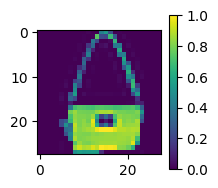

In [30]:
import torchvision.transforms as transforms

images, _ = next(iter(loaders['test']))
i = torch.randint(len(images), size=(1,)).item()
img = images[i]

plt.figure(figsize=(2, 2))
plt.imshow(img.squeeze())
plt.colorbar()
plt.show()

In [31]:
predictions = learner.model.predictions(img.to(device))
dict(sorted(predictions.items(), key=lambda item: item[1], reverse=True))

{'Bag': np.float32(0.9859569),
 'T-shirt/Top': np.float32(0.0060429093),
 'Dress': np.float32(0.00520719),
 'Sandal': np.float32(0.0011126293),
 'Pullover': np.float32(0.0007366813),
 'Coat': np.float32(0.0007079262),
 'Shirt': np.float32(0.00022886698),
 'Ankle-Boot': np.float32(3.5931048e-06),
 'Sneaker': np.float32(2.4266205e-06),
 'Trouser/Jeans': np.float32(7.825936e-07)}

In [32]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose(
    [
        transforms.Resize((28, 28)),
        transforms.Grayscale(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),  # Normalize
        transforms.Lambda(lambda x: 1.0 - x),  # Invert colors
        transforms.Lambda(lambda x: x[0]),
        transforms.Lambda(lambda x: x.unsqueeze(0)),
    ]
)

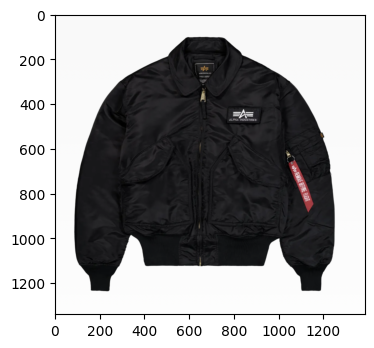

In [34]:
img = Image.open('images/jacket.png')
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

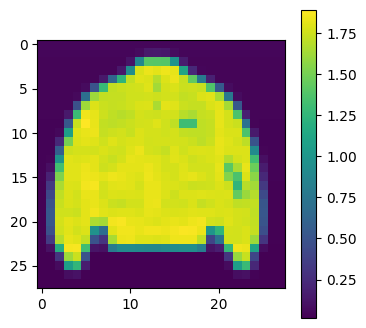

In [35]:
img = transform(img)
plt.figure(figsize=(4, 4))
plt.imshow(img.squeeze())
plt.colorbar()
plt.show()

In [36]:
learner.export('fashion.classifier.base.v0.pt')
model = torch.load('fashion.classifier.base.v0.pt')

predictions = model.predictions(img.to(device))
dict(sorted(predictions.items(), key=lambda item: item[1], reverse=True))

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.Classifier was not an allowed global by default. Please use `torch.serialization.add_safe_globals([Classifier])` or the `torch.serialization.safe_globals([Classifier])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weight